In [1]:
from functools import partial

import jax
import jax.numpy as jnp
import mediapy

key = jax.random.PRNGKey(0)

In [2]:
from omni_epic.envs.wall_is_lava import Env
from ppo.wrappers import EpisodeWrapper, AutoResetWrapper, LogWrapper, ClipAction, VecEnv, NormalizeVecObservation, NormalizeVecReward

env = Env()
env = EpisodeWrapper(env, episode_length=1000, action_repeat=1)
env = AutoResetWrapper(env)
env = LogWrapper(env)
env = ClipAction(env)
env = VecEnv(env)
# env = NormalizeVecObservation(env)
# env = NormalizeVecReward(env, 0.99)

In [3]:
reset_fn = jax.jit(env.reset)
step_fn = jax.jit(env.step)

num_envs = 16

In [ ]:
key, subkey = jax.random.split(key)
env_state = reset_fn(subkey)
images = [env.renderer(env_state)]
for _ in range(200):
	action = jnp.zeros(4)
	# action = action.at[0].set(0.2)
	key, subkey = jax.random.split(key)
	env_state = step_fn(subkey, env_state, action)
	images.append(env.renderer(env_state))
	print(_, env_state.terminated)

# Move robot
env_state = env.set_polygon_position(env_state, env.robot_idx, jnp.array([10.0, 10.0]))

for _ in range(10):
	action = jnp.zeros(4)
	key, subkey = jax.random.split(key)
	env_state = step_fn(subkey, env_state, action)
	images.append(env.renderer(env_state))
	print(_, env_state.terminated)

for _ in range(200):
	action = jnp.zeros(4)
	# action = -action.at[3].set(0.2)
	key, subkey = jax.random.split(key)
	env_state = step_fn(subkey, env_state, action)
	images.append(env.renderer(env_state))
	print(_, env_state.terminated)

In [4]:
mediapy.show_video(images)

NameError: name 'images' is not defined

In [4]:
key, subkey = jax.random.split(key)
keys = jax.random.split(subkey, num_envs)
env_state = reset_fn(keys)
env_states = [env_state]
for _ in range(200):
	action = jnp.zeros((num_envs, 4))
	# action = action.at[0].set(0.2)
	key, subkey = jax.random.split(key)
	keys = jax.random.split(subkey, num_envs)
	env_state = step_fn(keys, env_state, action)
	env_states.append(env_state)

# # Move robot
# env_state = env.set_polygon_position(env_state, env.robot_idx, jnp.array([10.0, 10.0]))

# for _ in range(10):
# 	action = jnp.zeros(4)
# 	key, subkey = jax.random.split(key)
# 	env_state = step_fn(subkey, env_state, action)
# 	images.append(env.renderer(env_state))
# 	print(_, env_state.terminated)

# for _ in range(200):
# 	action = jnp.zeros(4)
# 	# action = -action.at[3].set(0.2)
# 	key, subkey = jax.random.split(key)
# 	env_state = step_fn(subkey, env_state, action)
# 	images.append(env.renderer(env_state))
# 	print(_, env_state.terminated)

In [5]:
mediapy.show_video([env_state.observation["image"][3] for env_state in env_states])

""

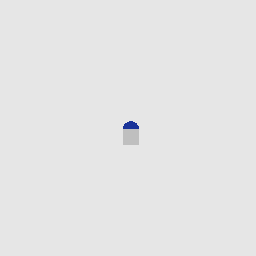

In [28]:
mediapy.show_image(env_states[0].observation["image"][1])

In [2]:
from omni_epic.envs.base import EnvBase
from omni_epic.jax2d.scene import add_rectangle_to_scene


class TestEnv(EnvBase):
	def __init__(self):
		super().__init__()

		obstacle_position = jnp.array([10.0, 5.0])
		self.init_state, (_, self.obstacle_idx) = add_rectangle_to_scene(
			self.init_state,
			self.static_sim_params,
			position=obstacle_position,
			dimensions=jnp.array([2.0, 2.0]),
			color=jnp.array([0.0, 0.2, 0.2]),
		)

		self.init_state = self.remove_polygon(self.init_state, self.floor_idx)

	@partial(jax.jit, static_argnames=("self",))
	def reset(self, key):
		state = super().reset()

		# Set initial position of the robot
		position = jax.random.uniform(key, (2,), minval=1.0, maxval=15.0)
		state = self.set_polygon_position(state, self.robot_idx, position)

		return state

	@partial(jax.jit, static_argnames=("self",))
	def step(self, state, action, key):
		actions = jnp.zeros(
			self.static_sim_params.num_joints + self.static_sim_params.num_thrusters
		)

		actions = self.apply_action(actions, action)
		state, reward, terminated, truncated, info = super().step(state, actions)

		return state, reward, terminated, truncated, info

	@partial(jax.jit, static_argnames=("self",))
	def get_task_rewards(self, state, manifolds, action):
		return {"distance_penalty": -self.dist_pp(state, self.robot_idx, self.ceiling_idx)}

	@partial(jax.jit, static_argnames=("self",))
	def get_terminated(self, state, manifolds, action):
		return ~self.collision_pp(manifolds, self.robot_idx, self.ceiling_idx)

	@partial(jax.jit, static_argnames=("self",))
	def get_truncated(self, state, manifolds, action):
		return jnp.array(False)

	@partial(jax.jit, static_argnames=("self",))
	def get_success(self, state, manifolds, action):
		return self.collision_pp(manifolds, self.robot_idx, self.ceiling_idx)


env = TestEnv()

## Check collisions

In [ ]:
state = env.reset(None)
action = jnp.zeros(env.static_sim_params.num_joints + env.static_sim_params.num_thrusters)
current_state, manifolds = env.step_fn(state, env.sim_params, action)
env.collision_pp(manifolds, env.robot_idx, env.obstacle_idx)